### TAREFA 1 – CONVOLUÇÃO COM MÁSCARAS DIVERSAS

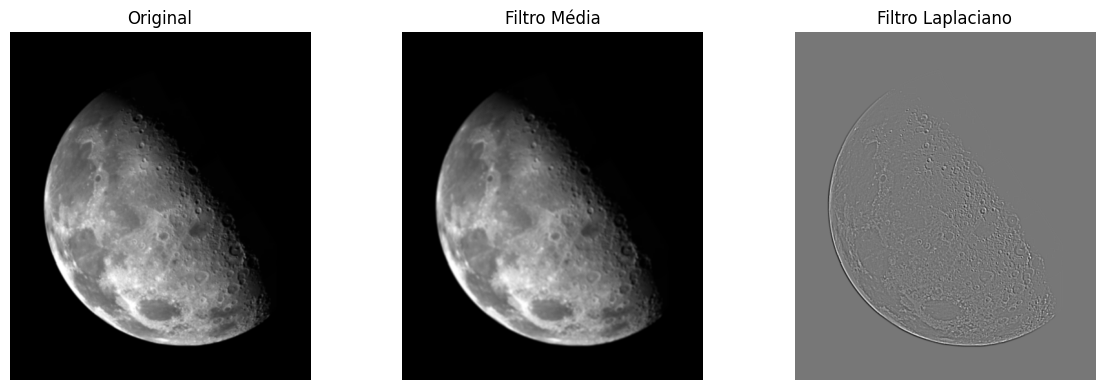

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import adjust_image  

# Carrega imagem em grayscale
image = cv2.imread('moon.png', cv2.IMREAD_GRAYSCALE)

# Máscara de média (suavização)
mask_media = (1/9) * np.ones((3,3), dtype=np.float32)

# Máscara laplaciana (aguçamento)
mask_laplace = np.array([ [-1, -1, -1], [-1,  8, -1], [-1, -1, -1] ], dtype=np.float32)

# Aplica os filtros
image_media = cv2.filter2D(image.astype(np.float32), -1, mask_media)
image_laplace = cv2.filter2D(image.astype(np.float32), -1, mask_laplace)

# Ajusta escala dos pixels
image_media_adj = adjust_image(image_media)
image_laplace_adj = adjust_image(image_laplace)

# Exibe os resultados
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Filtro Média')
plt.imshow(image_media_adj, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Filtro Laplaciano')
plt.imshow(image_laplace_adj, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


* Porque necessário converter a imagem para double, ao se utilizar a função imfilter()?

  As operações de convolução podem gerar valores negativos ou acima de 255. uint8 não suporta isso — causa estouro ou truncamento.  float32 evita esses erros e mantém a precisão
* Por que ajustar a escala de valores após a filtragem? 

  Porque a filtragem pode gerar valores fora da faixa [0, 255] (negativos ou maiores que 255), que não podem ser exibidos corretamente.

* O que as funções adjust_image (Python) e ajuste_image (MATLAB) fazem? 

  Elas normalizam os valores dos pixels para a faixa [0, 255], ajustando a imagem para exibição correta.

### TAREFA 2 – NITIDEZ e HIGHBOOST:

Implemente o filtro Nitidez e Highboost para a imagem moon.png.

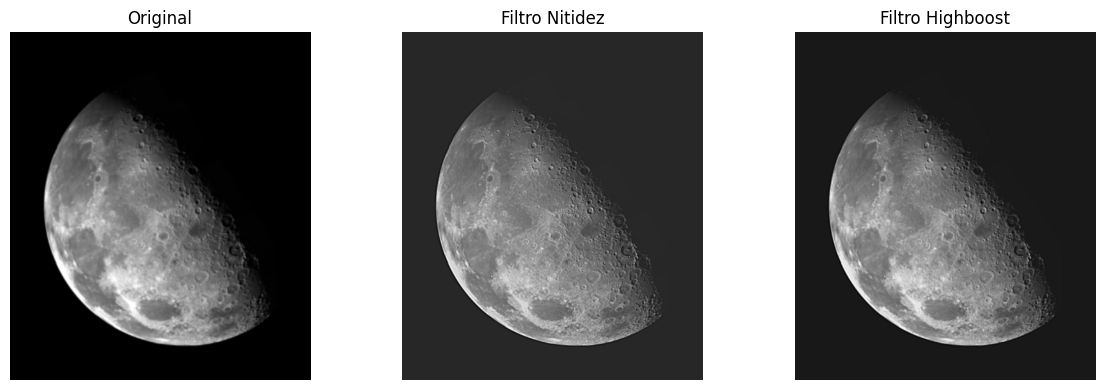

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import adjust_image  # Importa função adjust_image

# Carrega imagem em grayscale
image = cv2.imread('moon.png', cv2.IMREAD_GRAYSCALE)

# Máscara de média (suavização)
mask_media = (1/9) * np.ones((3,3), dtype=np.float32)

# Aplica o filtro de suavização (média)
image_media = cv2.filter2D(image.astype(np.float32), -1, mask_media)

# Filtro de Nitidez (Sharpening)
sharpening_mask = np.array([
    [0, -1, 0],
    [-1, 5,-1],
    [0, -1, 0]
], dtype=np.float32)

# Aplica o filtro de nitidez
image_sharpened = cv2.filter2D(image.astype(np.float32), -1, sharpening_mask)

# Filtro Highboost (realce)
k = 2  # Fator de amplificação para Highboost
image_highboost = cv2.filter2D(image.astype(np.float32), -1, mask_media)
image_highboost = image.astype(np.float32) + k * (image.astype(np.float32) - image_highboost)

# Ajusta a escala dos pixels
image_sharpened_adj = adjust_image(image_sharpened)
image_highboost_adj = adjust_image(image_highboost)

# Exibe os resultados
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Filtro Nitidez')
plt.imshow(image_sharpened_adj, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Filtro Highboost')
plt.imshow(image_highboost_adj, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


### TAREFA 3 – APLICAÇÃO
Calcular as regiões de transição (bordas) da imagem pompeii.tif e 
colorir   apenas   essas   regiões   de   verde,   mantendo   as   demais 
inalteradas.

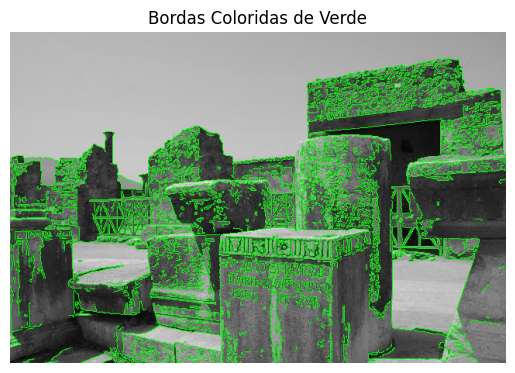

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carrega imagem em grayscale
image = cv2.imread('pompeii.tif', cv2.IMREAD_GRAYSCALE)

# Aplica o detector de bordas de Canny
edges = cv2.Canny(image, 100, 200)

# Cria uma imagem colorida (RGB), copiando a original
image_colored = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Onde houver bordas (valor 255), colore a região de verde
image_colored[edges == 255] = [0, 255, 0]  # Cor verde em RGB

# Exibe a imagem com bordas coloridas
plt.imshow(image_colored)
plt.title("Bordas Coloridas de Verde")
plt.axis('off')
plt.show()
